# Gradient Descent with a Fixed Step (trial and error for $\alpha$)

> 📖 Book: [ch04](../../.claude/skills/ml-knowledge/chapters/ch04-linear-regression-gradient-descent.md) · Prev: [02](02_gradient_descent_theory.ipynb) · Next: [04 Exact line search](04_gd_exact_line_search.ipynb)

This is the most common approach in ML practice: start with a small $\alpha$, say $0.01$, and increase it while the algorithm keeps converging. Failing to converge, or taking too long, means the step size is wrong:

- If $\alpha$ is too small, descent is slow.
- If $\alpha$ is too large, we overshoot the minimum and may diverge.

$$
\hat\theta^{(k+1)} = \hat\theta^{(k)} - \alpha\,\nabla J(\hat\theta^{(k)})
$$

Descent with a fixed $\alpha$ *can* converge: as we approach the minimum the gradient shrinks, so the actual step $\alpha\|\nabla J\|$ shrinks too. At the minimum $\nabla J = 0$ and $\theta$ stops moving.

## Example

Take

$$
A = X^TX = \begin{pmatrix} 10 & 0 \\ 0 & 1 \end{pmatrix}, \qquad b = X^Ty = \begin{pmatrix} 1 \\ -1 \end{pmatrix},
$$

which define the paraboloid

$$
J(\theta) = \frac12\theta^TA\theta - b^T\theta = 5\theta_0^2 + \frac12\theta_1^2 - \theta_0 + \theta_1 ,
$$

with minimum at $\theta^* = A^{-1}b = (0.1, -1)^T$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ml.linear_models import add_bias, mse_cost, mse_gradient
from ml.optimization import gradient_descent, quadratic
from ml.visualization.plots import plot_convergence, plot_cost_surface

plt.style.use("seaborn-v0_8-whitegrid")

A = np.array([[10.0, 0.0], [0.0, 1.0]])
b = np.array([1.0, -1.0])
cost, grad = quadratic(A, b)
theta0 = np.array([1.0, 1.0])

Start with $\alpha = 0.01$ and $\theta^{(0)} = (1, 1)^T$, stopping when $\|\nabla J\| < 0.01$.

In [2]:
runs = {}
for alpha in (0.01, 0.17, 0.21):
    _, runs[f"alpha = {alpha}"] = gradient_descent(cost, grad, theta0, alpha=alpha, tol=0.01, max_iter=1000)

pd.DataFrame(runs["alpha = 0.01"], columns=["theta0", "theta1", "J(theta)"]).iloc[[0, 1, 2, 3, -3, -2, -1]]

,theta0,theta1,J(theta)
0,1.0000,1.000000,5.500000
1,0.9100,0.980000,4.690700
2,0.8290,0.960200,4.028397
3,0.7561,0.940598,3.485296
526,0.1000,-0.989881,-0.549949
527,0.1000,-0.989982,-0.549950
528,0.1000,-0.990082,-0.549951


Plotting $J(\theta^{(k)})$ against the iteration number is **the** tool to debug gradient descent: if $J$ ever increases, decrease $\alpha$.

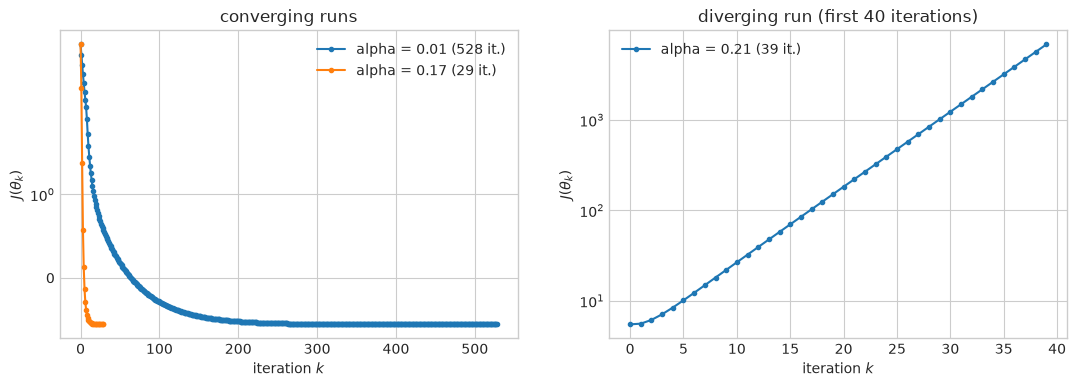

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
plot_convergence({k: v for k, v in runs.items() if k != "alpha = 0.21"}, ax=ax[0])
ax[0].set_title("converging runs")
plot_convergence({"alpha = 0.21": runs["alpha = 0.21"][:40]}, ax=ax[1])
ax[1].set_title("diverging run (first 40 iterations)")
plt.show()

- $\alpha = 0.01$ converges but needs hundreds of iterations.
- $\alpha = 0.21$ **diverges**: $J$ oscillates and grows.
- $\alpha = 0.17$ converges in a few dozen iterations.

Why is the threshold near $0.2$? Along an eigenvector of $A$ with eigenvalue $\lambda$ the error is multiplied by $(1 - \alpha\lambda)$ each step. Convergence needs $|1 - \alpha\lambda| < 1$ for every eigenvalue, i.e. $\alpha < 2/\lambda_{max} = 2/10 = 0.2$. The small eigenvalue $\lambda_{min} = 1$ then sets the slow direction: the elongated bowl (condition number $\kappa = 10$) is what makes fixed-step GD slow.

The path down to the minimum for $\alpha = 0.17$ (and the zig-zag of $\alpha = 0.19$ close to the limit):

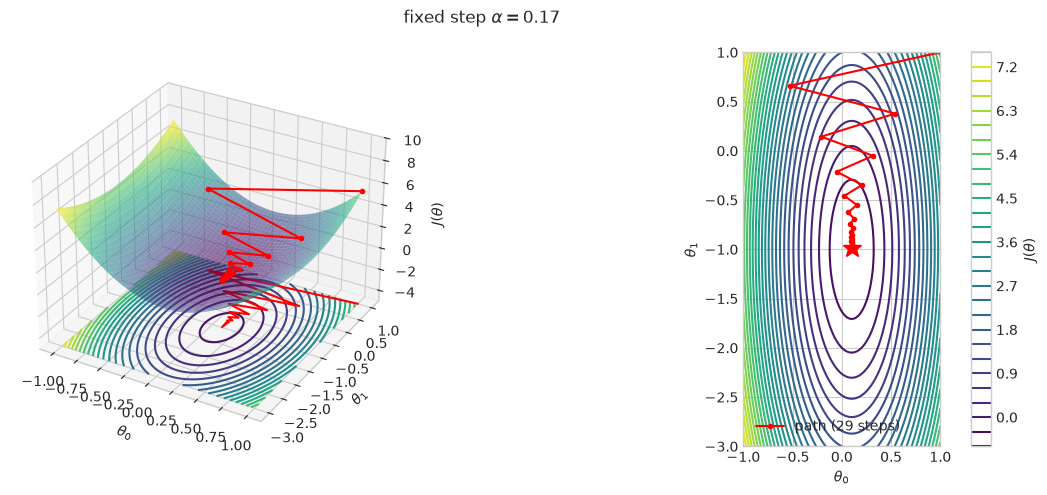

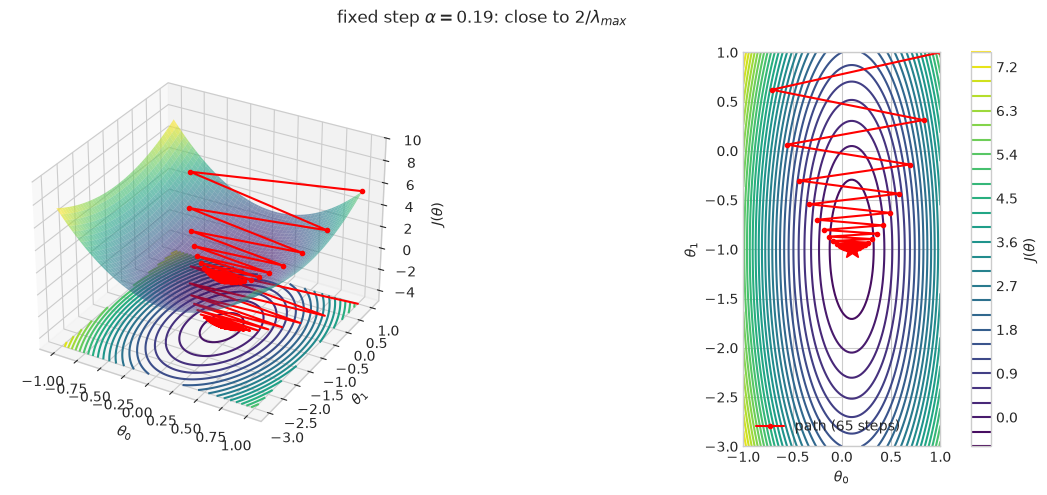

In [4]:
plot_cost_surface(cost, runs["alpha = 0.17"], zlim=(-5, 10), title=r"fixed step $\alpha = 0.17$")
plt.show()
_, h019 = gradient_descent(cost, grad, theta0, alpha=0.19, tol=0.01)
plot_cost_surface(cost, h019, zlim=(-5, 10), title=r"fixed step $\alpha = 0.19$: close to $2/\lambda_{max}$")
plt.show()

## Gradient descent for linear regression on data

Now with the MSE cost of a real regression, $J(\theta) = \frac{1}{2m}\|X\theta - y\|^2$ and $\nabla J = \frac1m X^T(X\theta - y)$, on noisy points around $y = x$. The update rule written component by component is

$$
\theta_j := \theta_j - \frac{\alpha}{m}\sum_{i=1}^m \left(h_\theta(x^{(i)}) - y^{(i)}\right)x_j^{(i)}, \qquad j = 0, \dots, n \quad \text{(simultaneously)}.
$$

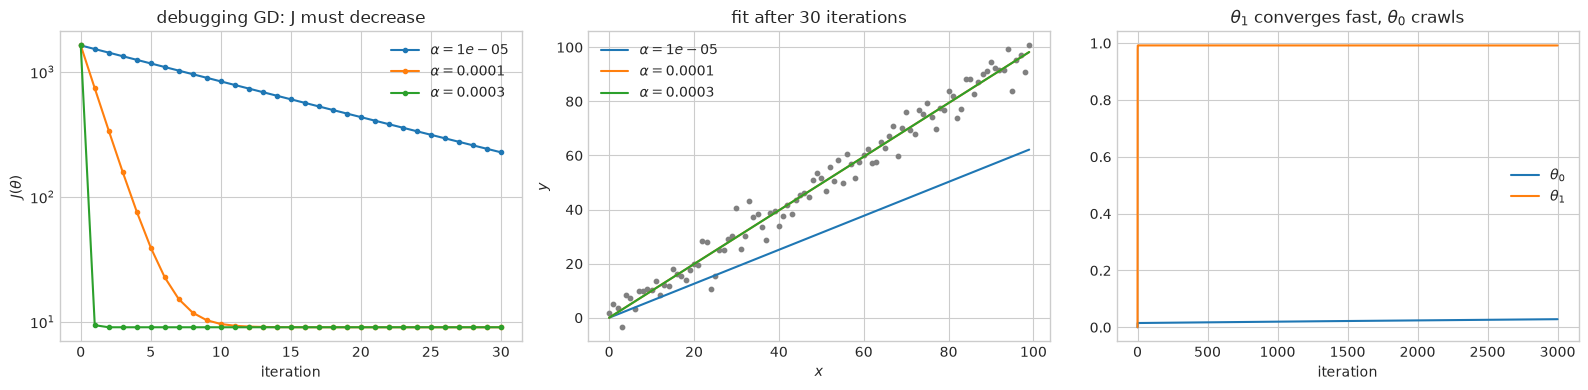

In [5]:
rng = np.random.default_rng(1)
m = 100
x = np.arange(m, dtype=float)
y = x + 5 * rng.normal(size=m)
X = add_bias(x)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for alpha in (1e-5, 1e-4, 3e-4):
    theta, hist = gradient_descent(
        lambda t: mse_cost(t, X, y), lambda t: mse_gradient(t, X, y), np.zeros(2), alpha=alpha, max_iter=30, tol=0
    )
    ax[0].plot(hist[:, -1], ".-", label=rf"$\alpha = {alpha:g}$")
    ax[1].plot(x, X @ theta, label=rf"$\alpha = {alpha:g}$")
ax[0].set(xlabel="iteration", ylabel=r"$J(\theta)$", yscale="log", title="debugging GD: J must decrease")
ax[0].legend()
ax[1].scatter(x, y, s=10, c="gray")
ax[1].set(xlabel="$x$", ylabel="$y$", title="fit after 30 iterations")
ax[1].legend()

# Why so few iterations are "enough" in theta_1 but not in theta_0: the unscaled feature
_, hist = gradient_descent(lambda t: mse_cost(t, X, y), lambda t: mse_gradient(t, X, y), np.zeros(2), alpha=3e-4, max_iter=3000, tol=0)
ax[2].plot(hist[:, 0], label=r"$\theta_0$")
ax[2].plot(hist[:, 1], label=r"$\theta_1$")
ax[2].set(xlabel="iteration", title=r"$\theta_1$ converges fast, $\theta_0$ crawls")
ax[2].legend()
plt.tight_layout()
plt.show()

The last panel shows the price of **unscaled features**: $x$ ranges up to 100, so $\theta_1$ has a huge curvature and $\theta_0$ (bias) a tiny one. The bowl is extremely elongated and a single $\alpha$ can't serve both directions. Feature scaling fixes this → [06 Multivariate regression and scaling](06_multivariate_and_feature_scaling.ipynb).

**Practical rules**

- It can be proven that for a small enough $\alpha$, $J$ decreases at every iteration.
- *Automatic convergence test*: declare convergence when $J$ decreases by less than $\varepsilon$ (e.g. $10^{-3}$) in one iteration. In practice it's hard to choose $\varepsilon$; looking at the curve is more reliable.
- Try $\alpha \in \{0.001, 0.003, 0.01, 0.03, 0.1, \dots\}$ (factors of ~3).